# **Helper Functions**

## Importing Dependencies

In [1]:
import time
import numpy as np
import os
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F

import seaborn
from sklearn.metrics import confusion_matrix

## Constants

In [2]:
SEED = 42
BATCH_SIZE = 128
CLASS_LABELS = ["airplaine", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

## Preprocessing Images and Creating Split

In [3]:
def set_seed(seed: int = SEED) -> None:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

def get_split(batch: int = BATCH_SIZE, workers: int=2, path: str = "./data"):
    """
    Returns a CIFAR10 train/val/test split as required using a set seed of 42 to ensure a consistent split of images throughout each run
    """

    # Required to normalize the images
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    # Defining the two transform sets that will be used on the dataset
    tf_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    tf_valTest = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    # Bifurcating transforms for each split
    ds_aug = torchvision.datasets.CIFAR10(path, train=True, download=True, transform=tf_train)
    ds_norm = torchvision.datasets.CIFAR10(path, train=True, download=False, transform=tf_valTest)
    ds_test = torchvision.datasets.CIFAR10(path, train=False, download=False, transform=tf_valTest)

    # Creating the split
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(50_000)
    tr_id = perm[:45_000] # Training Split = 45k images
    val_id = perm[45_000:] # Valudation Split = 5k images

    kw = dict(num_workers=workers, pin_memory=torch.cuda.is_available())

    train_split = DataLoader(Subset(ds_aug, tr_id), batch_size=batch, shuffle=True, **kw)
    val_split = DataLoader(Subset(ds_norm, val_id), batch_size=batch, shuffle=False, **kw)
    test_split = DataLoader(ds_test, batch_size=batch, shuffle=False, **kw)

    print(f"Data   : {len(tr_id):,} train | {len(val_id):,} val | {len(ds_test):,} test")

    return train_split, val_split, test_split

## Parameter Counting

In [4]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def print_hyperparams(**kwargs) -> None:
    print("\n" + "─" * 50)
    for k, v in kwargs.items():
        print(f"  {k:<18}: {v}")
    print("─" * 50)

## Training-Related Functions

In [ ]:
def _train_epoch(model, loader, crit, opt, device):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = crit(model(x), y)
        loss.backward()
        opt.step()
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)


@torch.no_grad()
def _eval_epoch(model, loader, crit, device):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    all_pred, all_true = [], []
    for x, y in loader:
        x, y    = x.to(device), y.to(device)
        out     = model(x)
        loss_sum += crit(out, y).item() * x.size(0)
        pred    = out.argmax(1)
        correct += pred.eq(y).sum().item()
        n       += y.size(0)
        all_pred.extend(pred.cpu().numpy())
        all_true.extend(y.cpu().numpy())
    return (loss_sum / n,
            100.0 * correct / n,
            np.array(all_pred),
            np.array(all_true))

def train_model(model, train_split, val_split,
                num_epochs, optimizer, scheduler=None, device=None):
    """
    Full training loop.  Returns a history dict with keys:
      train_loss, val_loss, val_acc, epoch_time
    """
    if device is None:
        device = "cuda:0"
    model.to(device)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_time": []}

    for ep in range(num_epochs):
        t0      = time.time()
        tr_loss = _train_epoch(model, train_split, crit, optimizer, device)
        vl_loss, vl_acc, _, _ = _eval_epoch(model, val_split, crit, device)
        dt      = time.time() - t0
        if scheduler:
            scheduler.step()

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(vl_loss)
        hist["val_acc"].append(vl_acc)
        hist["epoch_time"].append(dt)

        print(f"  Ep {ep+1:3d}/{num_epochs}  "
              f"TrLoss {tr_loss:.4f}  VlLoss {vl_loss:.4f}  "
              f"VlAcc {vl_acc:6.2f}%  ({dt:.1f}s)")

    return hist


@torch.no_grad()
def evaluate(model, loader, device):
    """Final evaluation on any loader — returns (loss, acc, preds, labels)."""
    model.to(device)
    return _eval_epoch(model, loader, nn.CrossEntropyLoss(), device)

## Graphing Functions

In [6]:
def save_training_curves(histories: dict, title: str, path: str) -> None:
    """
    histories: {label: history_dict}
    Produces a 3-panel figure: Training Loss | Validation Loss | Validation Accuracy
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    panels = [("train_loss", "Training Loss",     "Loss"),
              ("val_loss",   "Validation Loss",   "Loss"),
              ("val_acc",    "Validation Accuracy","Accuracy (%)")]

    for lbl, h in histories.items():
        for ax, (key, ttl, yl) in zip(axes, panels):
            ax.plot(h[key], label=lbl, linewidth=1.5)

    for ax, (_, ttl, yl) in zip(axes, panels):
        ax.set(title=ttl, xlabel="Epoch", ylabel=yl)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {path}")

def _cm(true, pred):
    return confusion_matrix(true, pred)

def save_confusion_matrix(true_labels, pred_labels, title: str, path: str) -> None:
    cm = _cm(true_labels, pred_labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    seaborn.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
                    linewidths=0.4, ax=ax)
    
    ax.set(title=title, xlabel="Predicted Label", ylabel="True Label")
    plt.tight_layout()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {path}")

def save_filter_visualization(model: nn.Module, title: str, path: str) -> None:
    """
    Visualises the learned filters of the first Conv2d layer.
    Filters with 3 input channels are shown as RGB patches;
    single-channel filters are shown with a 'viridis' colourmap.
    """
    first_conv = next(m for m in model.modules() if isinstance(m, nn.Conv2d))
    W = first_conv.weight.detach().cpu()          # [C_out, C_in, H, W]
    n = min(W.shape[0], 64)
    ncols = 8
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.5, nrows * 1.5))
    axes = np.array(axes).reshape(nrows, ncols)

    for i in range(nrows * ncols):
        ax = axes[i // ncols, i % ncols]
        if i < n:
            w = W[i]                              # [C_in, H, W]
            w = w - w.min()
            w = w / (w.max() + 1e-8)             # normalise to [0, 1]
            if w.shape[0] == 3:
                ax.imshow(w.permute(1, 2, 0).numpy())
            else:
                ax.imshow(w[0].numpy(), cmap="viridis")
        ax.axis("off")

    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {path}")

def save_accuracy_bar(names, accs, title: str, path: str) -> None:
    fig, ax = plt.subplots(figsize=(max(6, len(names) * 1.6), 5))
    colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(names)))
    bars = ax.bar(names, accs, color=colors, edgecolor="black", linewidth=0.7)
    for bar, a in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{a:.2f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold")
    ax.set(title=title, xlabel="Model", ylabel="Test Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {path}")

# For Question 3
def save_results(out_dir: str, data: dict) -> None:
    os.makedirs(out_dir, exist_ok=True)
    p = os.path.join(out_dir, "results.json")
    with open(p, "w") as f:
        json.dump(data, f, indent=2)
    print(f"  Saved → {p}")

def load_results(out_dir: str) -> dict:
    p = os.path.join(out_dir, "results.json")
    if not os.path.exists(p):
        return {}
    with open(p) as f:
        return json.load(f)

# **Question 3**

## Set-Up

In [7]:
# Configuring hyperparameters
learning_rate = 1e-3
weight_decay = 1e-4
NUM_EPOCHS = 50

out_path = "output/q3"
os.makedirs(out_path, exist_ok=True)

class BasicBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
 
        # Main
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
 
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
 
        # Skip 
        # Identity when dimensions match; 1×1 projection otherwise.
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()
    
    def forward(self, x):
        # Forward pass through the first convolution, batch norm, and ReLU activation
        out = F.relu(self.bn1(self.conv1(x)))
        # Forward pass through the second convolution and batch norm
        out = self.bn2(self.conv2(out))
        # Adding the shortcut connection's output to the main path's output
        out += self.shortcut(x)
        # Final ReLU activation after adding the shortcut
        out = F.relu(out)
        return out


class CIFAR10ResNet(nn.Module):
    def __init__(self, blocks_per_stage: list, num_classes: int = 10, dropout_rate: float = 0.0):
        super().__init__()

        # Initial Layer adapted from/to CIFAR10
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)

        # Stage 1: stride=1, no downsampling, channels stay at 64
        # Stages 2–4: stride=2 in first block, channel count doubles each stage
        self.stage1 = self._make_stage(  64,  64, blocks_per_stage[0], stride=1)
        self.stage2 = self._make_stage(  64, 128, blocks_per_stage[1], stride=2)
        self.stage3 = self._make_stage( 128, 256, blocks_per_stage[2], stride=2)
        self.stage4 = self._make_stage( 256, 512, blocks_per_stage[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))   # [B, 512, 4, 4] → [B, 512, 1, 1]
        self.dropout = nn.Dropout(p=dropout_rate)     # identity when p=0.0
        self.fc      = nn.Linear(512, num_classes)

        self._init_weights()

    @staticmethod
    def _make_stage(in_channels: int, out_channels: int, num_blocks: int, stride: int):
        layers = [BasicBlock(in_channels, out_channels, stride=stride)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias,   0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.stage1(x)                   
        x = self.stage2(x)                  
        x = self.stage3(x)                  
        x = self.stage4(x)                  
        x = self.avgpool(x)                 
        x = torch.flatten(x, 1)             
        x = self.dropout(x)                 
        x = self.fc(x)                       
        return x

def build_resnet11(num_classes: int = 10, dropout_rate: float = 0.0):
    return CIFAR10ResNet([1, 1, 1, 1], num_classes, dropout_rate)

def build_resnet18(num_classes: int = 10, dropout_rate: float = 0.0):
    return CIFAR10ResNet([2, 2, 2, 2], num_classes, dropout_rate)

def make_opt_sched(model):
    opt   = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    return opt, sched

def convergence_epoch(val_acc_list, threshold=0.80):
    target = threshold * val_acc_list[-1]
    for i, acc in enumerate(val_acc_list):
        if acc >= target:
            return i + 1
    return len(val_acc_list)

## **Part 3A**

In [ ]:
def part_a(train_split, val_split, test_split, device) -> dict:
    print("\n" + "=" * 60)
    print("Question 3: Part A")
    print("=" * 60)

    baseline_results = {}
    histories        = {}

    for name, build_fn in [("ResNet-11", build_resnet11),
                            ("ResNet-18", build_resnet18)]:
        print(f"\n{'─'*60}")
        print(f"  Training {name} baseline")
        print(f"{'─'*60}")

        set_seed(SEED)
        model  = build_fn(dropout_rate=0.0)
        params = count_parameters(model)

        print(f"\n  {name} parameter count : {params:,}")
        print(f"\n  Layer-wise breakdown:")
        for pname, p in model.named_parameters():
            print(f"    {pname:<52} {p.numel():>10,}")
        print(f"    {'TOTAL':<52} {params:>10,}")

        print_hyperparams(
            Problem=f"3A — {name}",
            Model=f"{name} (dropout=0.0)",
            Epochs=NUM_EPOCHS,
            BatchSize=BATCH_SIZE,
            Optimizer=f"Adam lr={learning_rate} wd={weight_decay}",
            Scheduler=f"CosineAnnealingLR T_max={NUM_EPOCHS}",
            Device=device,
            Seed=SEED,
        )

        opt, sched = make_opt_sched(model)
        history    = train_model(model, train_split, val_split,
                                 NUM_EPOCHS, opt, sched, device)

        _, test_acc, preds, labels = evaluate(model, test_split, device)
        print(f"\n  Final Test Accuracy ({name}): {test_acc:.2f}%")

        avg_time = sum(history["epoch_time"]) / len(history["epoch_time"])
        conv_ep  = convergence_epoch(history["val_acc"])

        baseline_results[name] = {
            "model"    : model,
            "history"  : history,
            "test_acc" : test_acc,
            "params"   : params,
            "preds"    : preds,
            "labels"   : labels,
            "avg_time" : avg_time,
            "conv_ep"  : conv_ep,
        }

        tag = f"{name} baseline"
        histories[tag] = history

        # Individual output files
        suffix = "r11" if "11" in name else "r18"
        save_training_curves(
            {tag: history},
            f"{name} — Training Curves (Part A)",
            f"{out_path}/3a_{suffix}_curves.png",
        )
        save_confusion_matrix(
            labels, preds,
            f"{name} — Confusion Matrix  (Test Acc: {test_acc:.2f}%)",
            f"{out_path}/p3a_{suffix}_cm.png",
        )

    # ── Overlaid comparison curves ────────────────────────────────────────────
    save_training_curves(
        histories,
        "ResNet-11 vs ResNet-18 Training Curves: Part A",
        f"{out_path}/3a_resnet_comparison.png",
    )

    # ── Comparison table ──────────────────────────────────────────────────────
    r11 = baseline_results["ResNet-11"]
    r18 = baseline_results["ResNet-18"]

    print("\n─── ResNet-11 vs ResNet-18 Comparison ──────────────────────────")
    print(f"  {'Metric':<35} {'ResNet-11':>12} {'ResNet-18':>12}")
    print(f"  {'─'*60}")
    print(f"  {'Parameters':35} {r11['params']:>12,} {r18['params']:>12,}")
    print(f"  {'Test Accuracy (%)':35} {r11['test_acc']:>12.2f} {r18['test_acc']:>12.2f}")
    print(f"  {'Avg Epoch Time (s)':35} {r11['avg_time']:>12.1f} {r18['avg_time']:>12.1f}")
    print(f"  {'Epoch to 80% of final val acc':35} {r11['conv_ep']:>12} {r18['conv_ep']:>12}")

    rows = [
        ["Parameters",             f"{r11['params']:,}",     f"{r18['params']:,}"],
        ["Test Accuracy (%)",       f"{r11['test_acc']:.2f}", f"{r18['test_acc']:.2f}"],
        ["Avg Epoch Time (s)",      f"{r11['avg_time']:.1f}", f"{r18['avg_time']:.1f}"],
        ["Epoch to 80% final acc",  str(r11['conv_ep']),       str(r18['conv_ep'])],
    ]
    
    return baseline_results

# **Part 3B**

In [ ]:
def part_b(baseline_results: dict, train_split, val_split, test_split, device, p1_results: dict, p2_results: dict) -> dict:
    print("\n" + "=" * 60)
    print("Question 3: Part B")
    print("=" * 60)

    # dropout_accs[model_name][dropout_key] = test_acc
    dropout_accs = {
        "ResNet-11": {"p=0.0": baseline_results["ResNet-11"]["test_acc"]},
        "ResNet-18": {"p=0.0": baseline_results["ResNet-18"]["test_acc"]},
    }

    build_fns = {"ResNet-11": build_resnet11, "ResNet-18": build_resnet18}
    suffixes  = {"ResNet-11": "r11",          "ResNet-18": "r18"}

    for model_name, build_fn in build_fns.items():
        print(f"\n{'='*60}")
        print(f"  Dropout study: {model_name}")
        print(f"{'='*60}")

        suffix    = suffixes[model_name]
        histories = {f"{model_name} p=0.0": baseline_results[model_name]["history"]}

        for p in [0.3, 0.5]:
            print(f"\n{model_name}  dropout p={p}")
            set_seed(SEED)
            model      = build_fn(dropout_rate=p)
            opt, sched = make_opt_sched(model)
            history    = train_model(model, train_split, val_split, NUM_EPOCHS, opt, sched, device)

            _, test_acc, preds, labels = evaluate(model, test_split, device)
            print(f"  Test Accuracy ({model_name}, p={p}): {test_acc:.2f}%")

            tag = f"{model_name} p={p}"
            histories[tag]                       = history
            dropout_accs[model_name][f"p={p}"]  = test_acc

            fname = f"p03" if p == 0.3 else "p05"
            save_confusion_matrix(
                labels, preds,
                f"{model_name} (p={p}) — Confusion Matrix  (Test Acc: {test_acc:.2f}%)",
                f"{out_path}/3b_{suffix}_cm_{fname}.png",
            )

        # Dropout comparison curves (baseline + p=0.3 + p=0.5)
        save_training_curves(
            histories,
            f"{model_name} — Dropout Comparison (Part B)",
            f"{out_path}/3b_{suffix}_dropout.png",
        )

        # Train/Val gap table for this model
        print(f"\n {model_name} Train/Val Gap Analysis")
        print(f"  {'Variant':<25} {'TrLoss':>10} {'VlLoss':>10} {'Gap (Tr-Vl)':>12} {'VlAcc':>8}")
        print(f"  {'─'*68}")
        for lbl, h in histories.items():
            tr = h["train_loss"][-1]
            vl = h["val_loss"][-1]
            ac = h["val_acc"][-1]
            print(f"  {lbl:<25} {tr:>10.4f} {vl:>10.4f} {tr-vl:>12.4f} {ac:>7.2f}%")

    # ResNet Dropout Summary
    print("\nCross-ResNet Dropout Summary")
    print(f"  {'Variant':<28} {'Test Acc (%)':>13}")
    print(f"  {'─'*43}")
    for mname, d in dropout_accs.items():
        for dkey, acc in d.items():
            print(f"  {mname + ' ' + dkey:<28} {acc:>13.2f}")
    
    # Cross-Architecture Comparison
    print("\n" + "=" * 60)
    print("FINAL CROSS-ARCHITECTURE COMPARISON")
    print("=" * 60)

    def _best(d: dict, *keys: str) -> float:
        """Highest value among the given keys, defaulting to 0.0 if missing."""
        return max(d.get(k, 0.0) for k in keys)

    bar_names = []
    bar_accs  = []

    if p1_results:
        bar_names.append("AlexNet (best)")
        bar_accs.append(_best(p1_results, "baseline_acc", "dropout_03_acc", "dropout_05_acc"))

    if p2_results:
        bar_names.append("VGG-11 (best)")
        bar_accs.append(_best(p2_results, "baseline_acc", "dropout_03_acc", "dropout_05_acc"))

    best_r11 = max(dropout_accs["ResNet-11"].values())
    best_r18 = max(dropout_accs["ResNet-18"].values())
    bar_names += ["ResNet-11 (best)", "ResNet-18 (best)"]
    bar_accs  += [best_r11, best_r18]

    save_accuracy_bar(
        bar_names, bar_accs,
        "Final Cross-Architecture Comparison — Best Test Accuracy",
        f"{out_path}/3b_final_comparison.png",
    )

    print(f"\n  {'Architecture':<22} {'Best Acc (%)':>13}")
    print(f"  {'─'*37}")
    for name, acc in zip(bar_names, bar_accs):
        print(f"  {name:<22} {acc:>13.2f}")

    return dropout_accs

# Main Function

Question 3: ResNet-11 vs ResNet-18 on CIFAR-10
Random seed : 42

Loaded P1 results
 AlexNet best acc: 85.50%
Loaded P2 results
 VGG-11 best acc: 81.26%
Using device: cuda:0
Data   : 45,000 train | 5,000 val | 10,000 test

Question 3: Part A

────────────────────────────────────────────────────────────
  Training ResNet-11 baseline
────────────────────────────────────────────────────────────

  ResNet-11 parameter count : 4,903,242

  Layer-wise breakdown:
    conv1.weight                                              1,728
    bn1.weight                                                   64
    bn1.bias                                                     64
    stage1.0.conv1.weight                                    36,864
    stage1.0.bn1.weight                                          64
    stage1.0.bn1.bias                                            64
    stage1.0.conv2.weight                                    36,864
    stage1.0.bn2.weight                                         

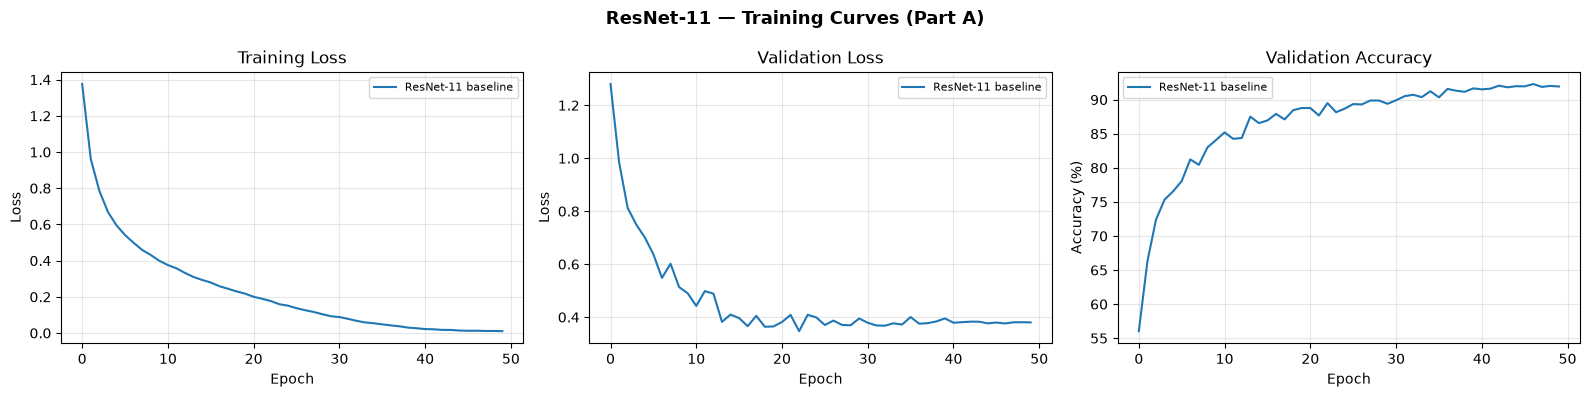

  Saved → output/q3/3a_r11_curves.png


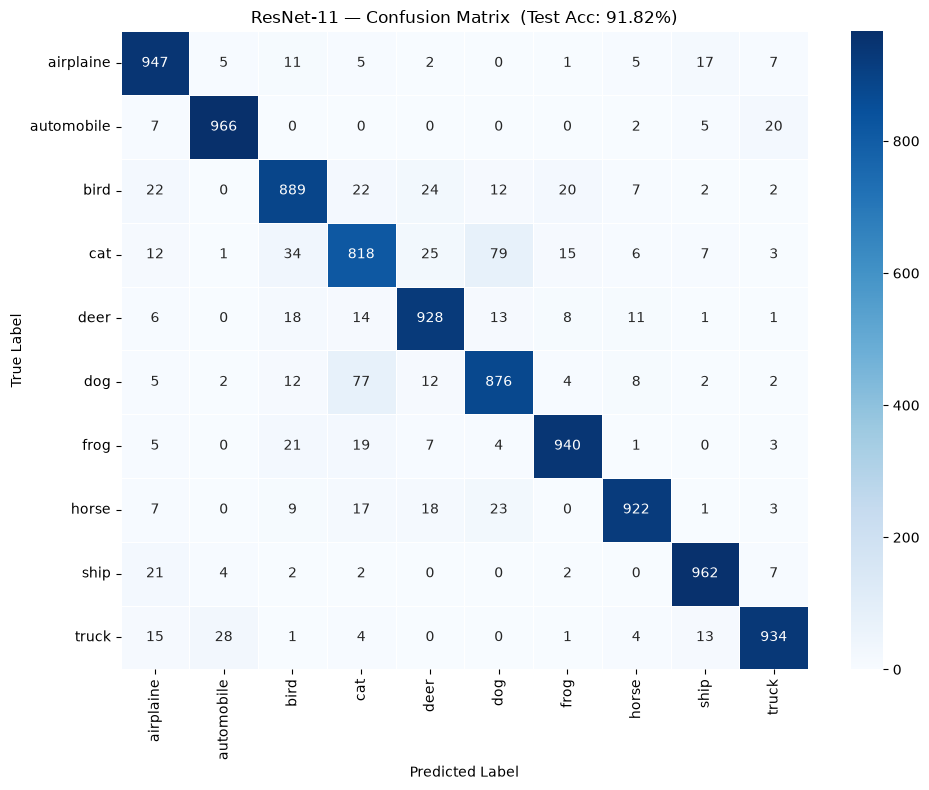

  Saved → output/q3/p3a_r11_cm.png

────────────────────────────────────────────────────────────
  Training ResNet-18 baseline
────────────────────────────────────────────────────────────

  ResNet-18 parameter count : 11,173,962

  Layer-wise breakdown:
    conv1.weight                                              1,728
    bn1.weight                                                   64
    bn1.bias                                                     64
    stage1.0.conv1.weight                                    36,864
    stage1.0.bn1.weight                                          64
    stage1.0.bn1.bias                                            64
    stage1.0.conv2.weight                                    36,864
    stage1.0.bn2.weight                                          64
    stage1.0.bn2.bias                                            64
    stage1.1.conv1.weight                                    36,864
    stage1.1.bn1.weight                                          

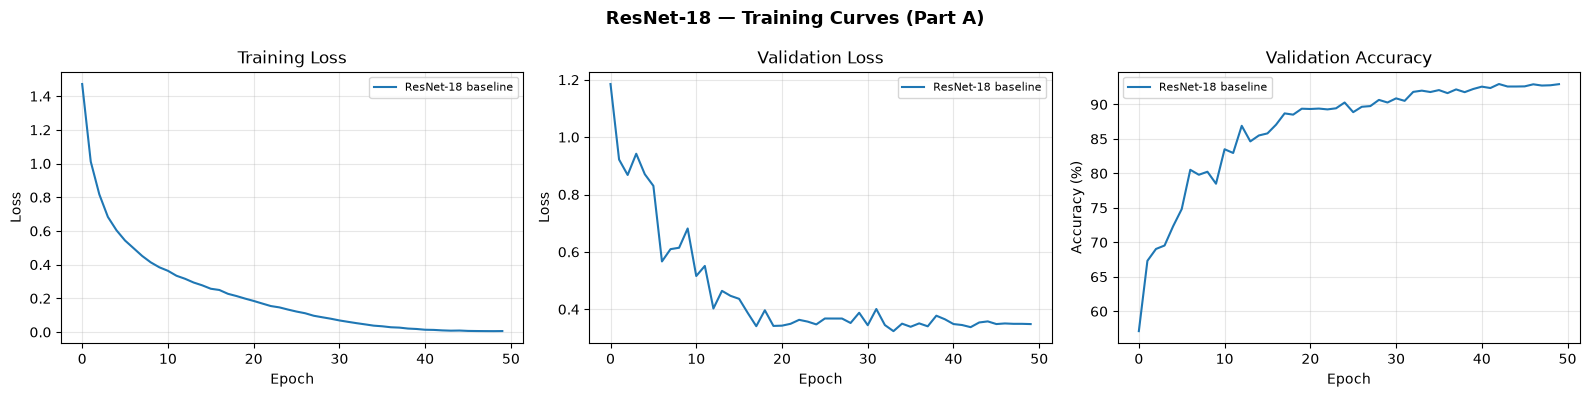

  Saved → output/q3/3a_r18_curves.png


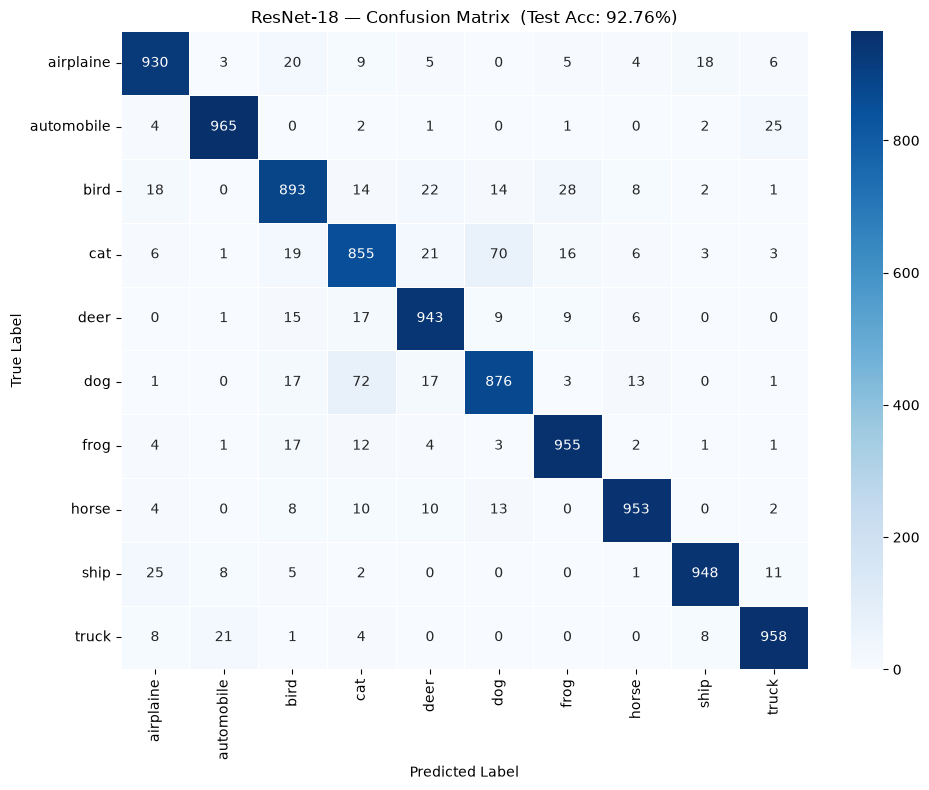

  Saved → output/q3/p3a_r18_cm.png


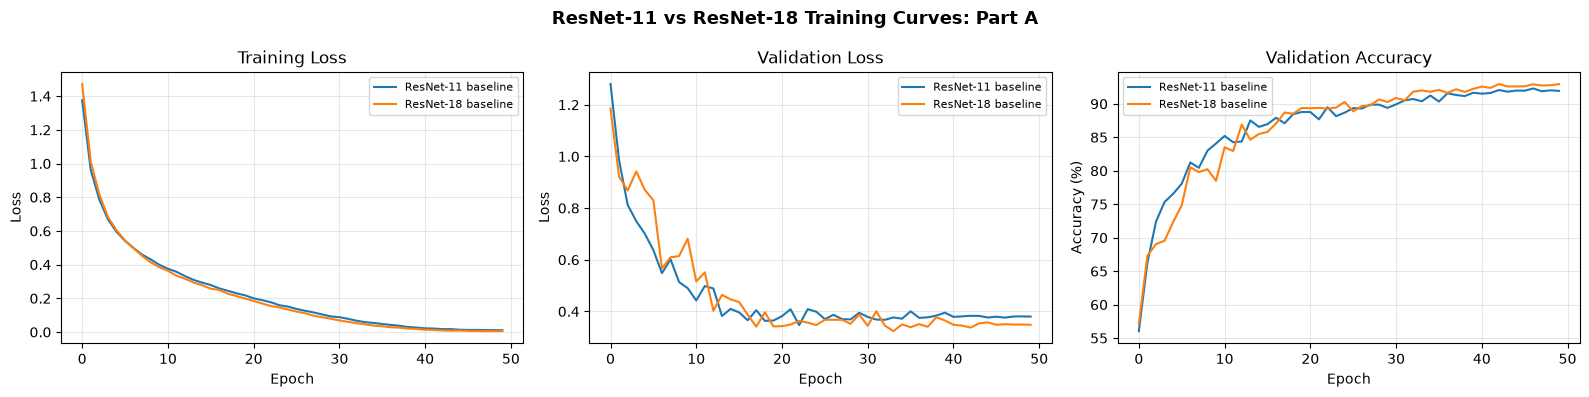

  Saved → output/q3/3a_resnet_comparison.png

─── ResNet-11 vs ResNet-18 Comparison ──────────────────────────
  Metric                                 ResNet-11    ResNet-18
  ────────────────────────────────────────────────────────────
  Parameters                             4,903,242   11,173,962
  Test Accuracy (%)                          91.82        92.76
  Avg Epoch Time (s)                          13.6         26.3
  Epoch to 80% of final val acc                  4            6

Question 3: Part B

  Dropout study: ResNet-11

ResNet-11  dropout p=0.3
  Ep   1/50  TrLoss 1.3990  VlLoss 1.1028  VlAcc  60.36%  (14.4s)
  Ep   2/50  TrLoss 0.9920  VlLoss 0.9932  VlAcc  65.30%  (14.4s)
  Ep   3/50  TrLoss 0.8141  VlLoss 0.8723  VlAcc  70.22%  (14.1s)
  Ep   4/50  TrLoss 0.6918  VlLoss 0.7227  VlAcc  75.80%  (14.1s)
  Ep   5/50  TrLoss 0.6105  VlLoss 0.6668  VlAcc  77.28%  (14.5s)
  Ep   6/50  TrLoss 0.5550  VlLoss 0.6347  VlAcc  78.86%  (14.7s)
  Ep   7/50  TrLoss 0.5113  VlLoss 0

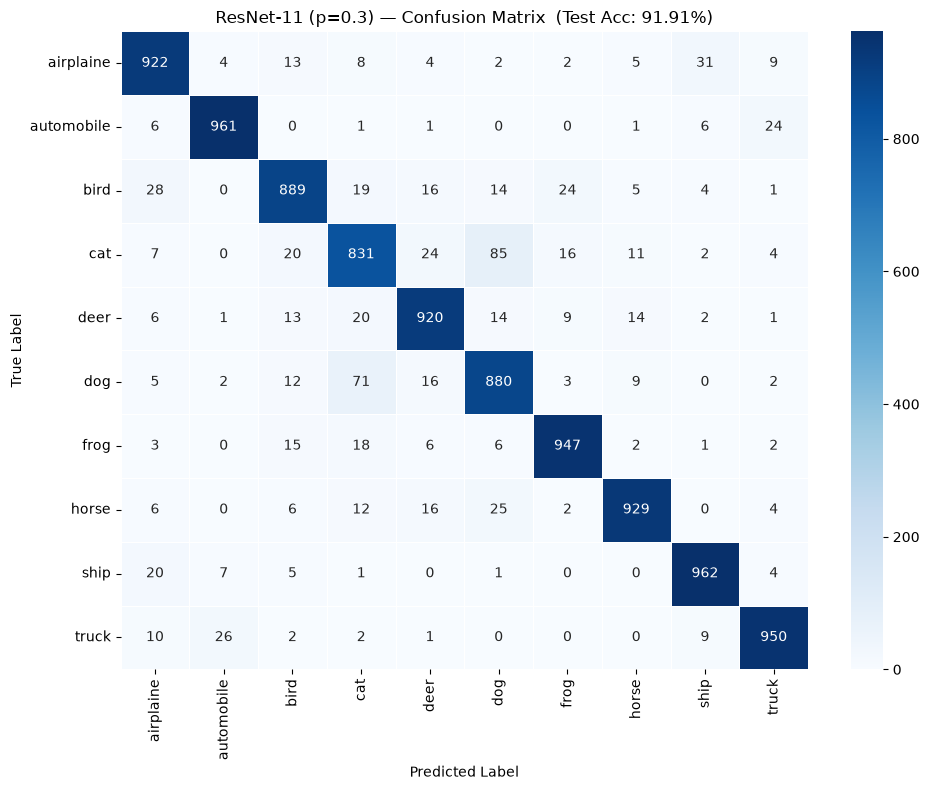

  Saved → output/q3/3b_r11_cm_p03.png

ResNet-11  dropout p=0.5
  Ep   1/50  TrLoss 1.4260  VlLoss 1.1936  VlAcc  57.32%  (13.0s)
  Ep   2/50  TrLoss 1.0221  VlLoss 0.9931  VlAcc  65.08%  (12.8s)
  Ep   3/50  TrLoss 0.8492  VlLoss 0.9103  VlAcc  69.38%  (12.6s)
  Ep   4/50  TrLoss 0.7184  VlLoss 0.6921  VlAcc  76.46%  (13.1s)
  Ep   5/50  TrLoss 0.6327  VlLoss 0.7230  VlAcc  75.78%  (12.9s)
  Ep   6/50  TrLoss 0.5689  VlLoss 0.6674  VlAcc  77.94%  (13.2s)
  Ep   7/50  TrLoss 0.5296  VlLoss 0.6695  VlAcc  77.30%  (13.0s)
  Ep   8/50  TrLoss 0.4817  VlLoss 0.5627  VlAcc  80.94%  (13.0s)
  Ep   9/50  TrLoss 0.4504  VlLoss 0.5036  VlAcc  83.34%  (13.0s)
  Ep  10/50  TrLoss 0.4189  VlLoss 0.5390  VlAcc  82.86%  (12.9s)
  Ep  11/50  TrLoss 0.3923  VlLoss 0.4272  VlAcc  85.02%  (12.7s)
  Ep  12/50  TrLoss 0.3685  VlLoss 0.4602  VlAcc  84.90%  (12.8s)
  Ep  13/50  TrLoss 0.3455  VlLoss 0.4757  VlAcc  84.46%  (12.9s)
  Ep  14/50  TrLoss 0.3261  VlLoss 0.3869  VlAcc  87.06%  (13.3s)
  Ep  15/50 

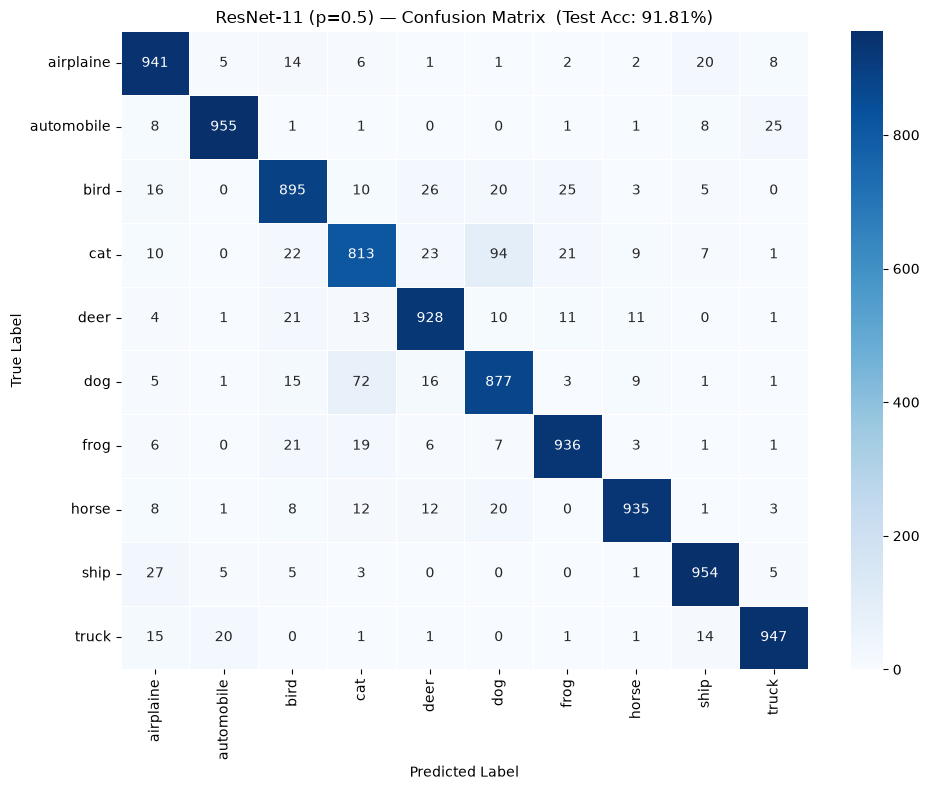

  Saved → output/q3/3b_r11_cm_p05.png


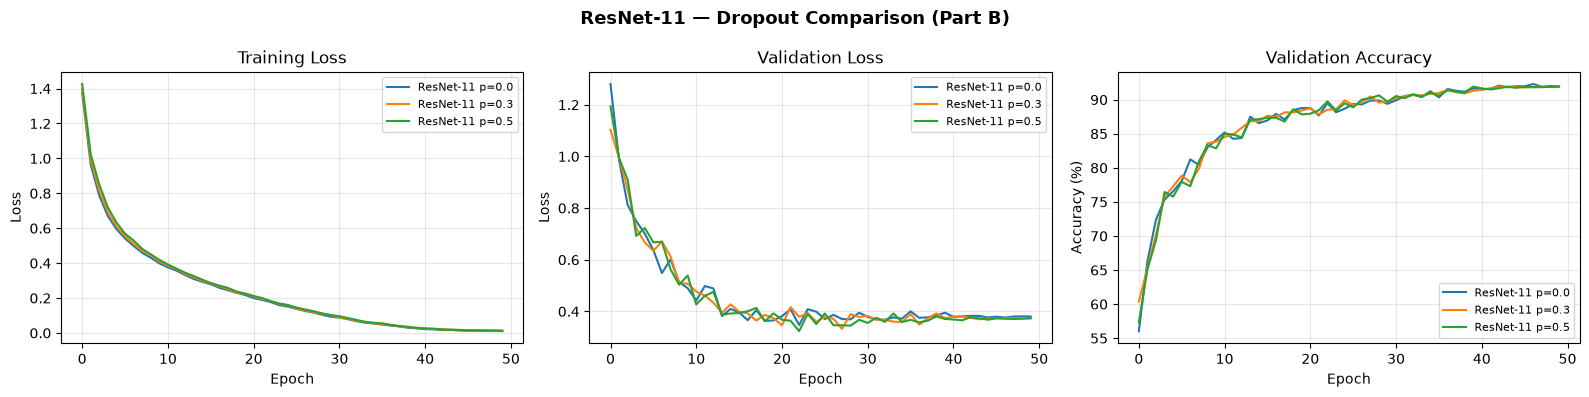

  Saved → output/q3/3b_r11_dropout.png

 ResNet-11 Train/Val Gap Analysis
  Variant                       TrLoss     VlLoss  Gap (Tr-Vl)    VlAcc
  ────────────────────────────────────────────────────────────────────
  ResNet-11 p=0.0               0.0105     0.3801      -0.3696   91.94%
  ResNet-11 p=0.3               0.0129     0.3731      -0.3602   91.98%
  ResNet-11 p=0.5               0.0131     0.3740      -0.3609   91.90%

  Dropout study: ResNet-18

ResNet-18  dropout p=0.3
  Ep   1/50  TrLoss 1.4492  VlLoss 1.1798  VlAcc  57.50%  (29.9s)
  Ep   2/50  TrLoss 0.9943  VlLoss 1.0447  VlAcc  64.04%  (26.7s)
  Ep   3/50  TrLoss 0.8221  VlLoss 0.7775  VlAcc  72.74%  (25.3s)
  Ep   4/50  TrLoss 0.6989  VlLoss 0.9075  VlAcc  70.16%  (24.2s)
  Ep   5/50  TrLoss 0.6170  VlLoss 0.9323  VlAcc  71.60%  (24.7s)
  Ep   6/50  TrLoss 0.5588  VlLoss 0.8092  VlAcc  75.06%  (27.2s)
  Ep   7/50  TrLoss 0.5189  VlLoss 0.4964  VlAcc  82.60%  (26.8s)
  Ep   8/50  TrLoss 0.4713  VlLoss 0.5574  VlAcc  8

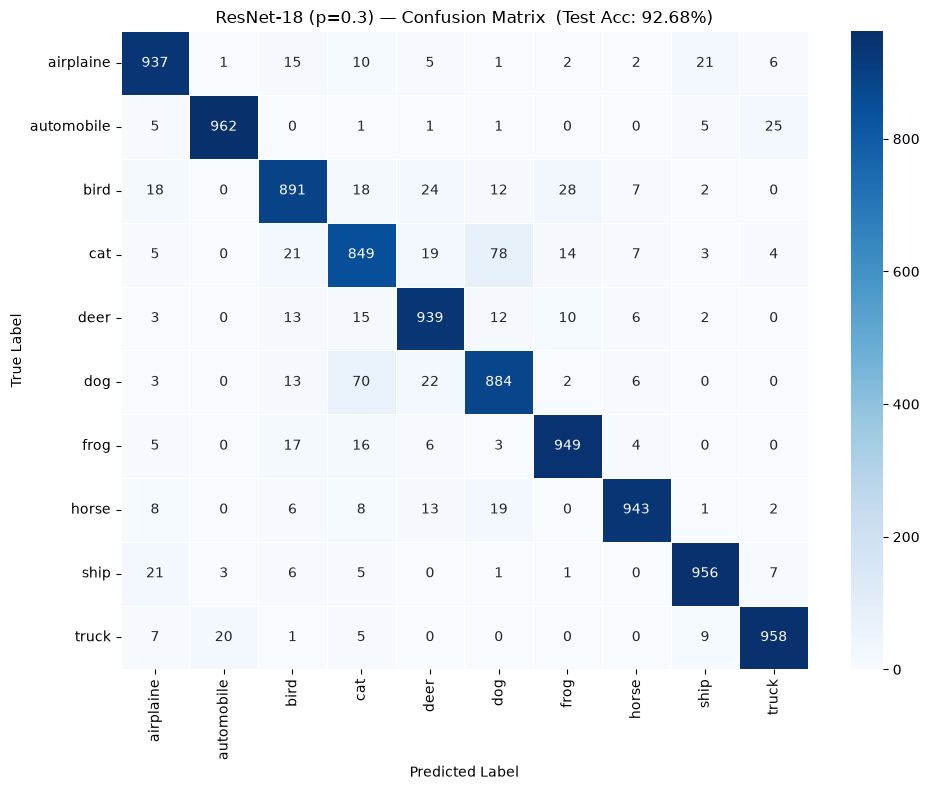

  Saved → output/q3/3b_r18_cm_p03.png

ResNet-18  dropout p=0.5
  Ep   1/50  TrLoss 1.4834  VlLoss 1.2635  VlAcc  54.92%  (25.8s)
  Ep   2/50  TrLoss 1.0206  VlLoss 1.0499  VlAcc  63.18%  (25.8s)
  Ep   3/50  TrLoss 0.8389  VlLoss 0.9476  VlAcc  67.66%  (25.8s)
  Ep   4/50  TrLoss 0.7060  VlLoss 0.7625  VlAcc  74.12%  (25.8s)
  Ep   5/50  TrLoss 0.6287  VlLoss 0.6439  VlAcc  78.26%  (25.8s)
  Ep   6/50  TrLoss 0.5682  VlLoss 0.8010  VlAcc  76.08%  (25.8s)
  Ep   7/50  TrLoss 0.5257  VlLoss 0.4873  VlAcc  83.50%  (25.8s)
  Ep   8/50  TrLoss 0.4764  VlLoss 0.5716  VlAcc  81.12%  (25.8s)
  Ep   9/50  TrLoss 0.4417  VlLoss 0.7263  VlAcc  77.62%  (25.8s)
  Ep  10/50  TrLoss 0.4109  VlLoss 0.5388  VlAcc  81.82%  (25.8s)
  Ep  11/50  TrLoss 0.3856  VlLoss 0.5296  VlAcc  82.94%  (25.8s)
  Ep  12/50  TrLoss 0.3581  VlLoss 0.4181  VlAcc  86.48%  (26.0s)
  Ep  13/50  TrLoss 0.3387  VlLoss 0.5303  VlAcc  83.80%  (26.0s)
  Ep  14/50  TrLoss 0.3170  VlLoss 0.4671  VlAcc  85.20%  (25.7s)
  Ep  15/50 

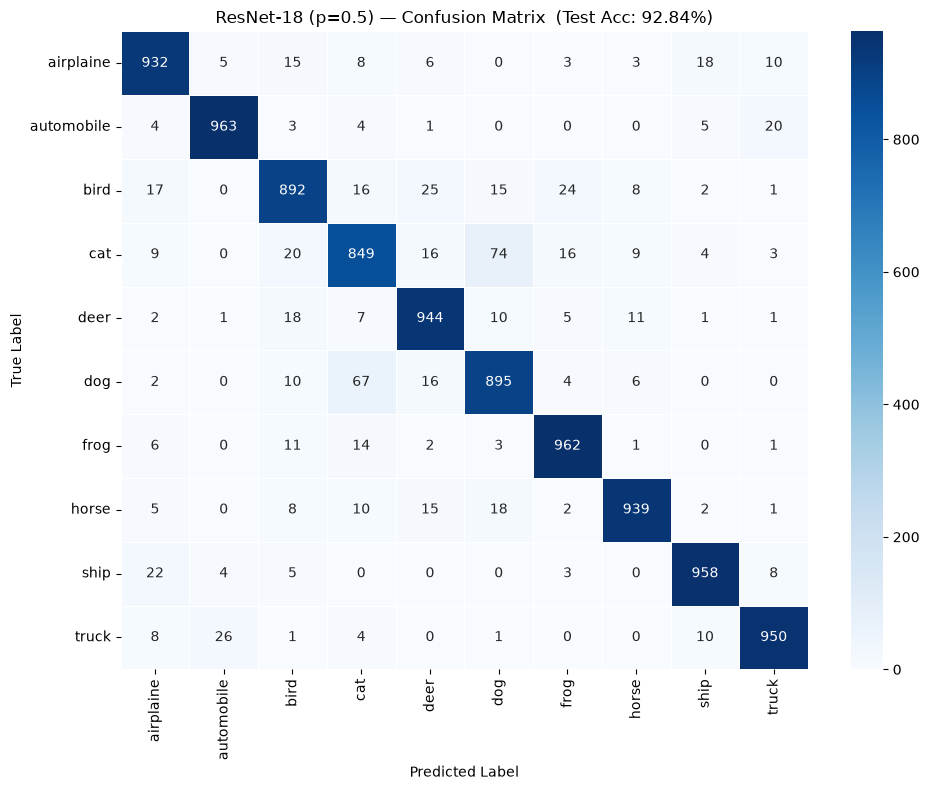

  Saved → output/q3/3b_r18_cm_p05.png


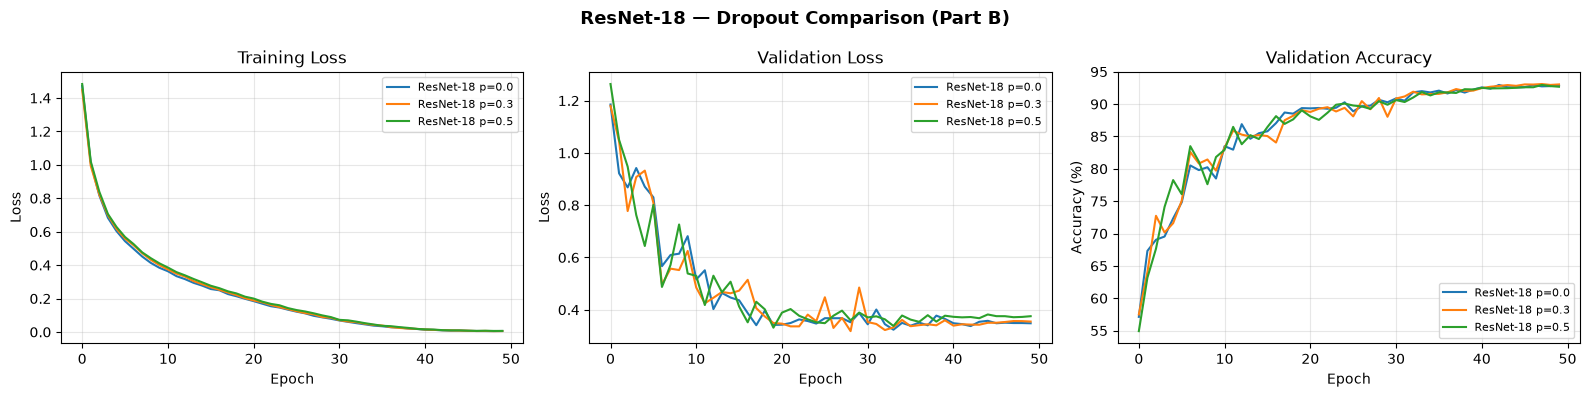

  Saved → output/q3/3b_r18_dropout.png

 ResNet-18 Train/Val Gap Analysis
  Variant                       TrLoss     VlLoss  Gap (Tr-Vl)    VlAcc
  ────────────────────────────────────────────────────────────────────
  ResNet-18 p=0.0               0.0059     0.3484      -0.3425   92.94%
  ResNet-18 p=0.3               0.0056     0.3549      -0.3494   93.04%
  ResNet-18 p=0.5               0.0065     0.3754      -0.3689   92.68%

Cross-ResNet Dropout Summary
  Variant                       Test Acc (%)
  ───────────────────────────────────────────
  ResNet-11 p=0.0                      91.82
  ResNet-11 p=0.3                      91.91
  ResNet-11 p=0.5                      91.81
  ResNet-18 p=0.0                      92.76
  ResNet-18 p=0.3                      92.68
  ResNet-18 p=0.5                      92.84

FINAL CROSS-ARCHITECTURE COMPARISON


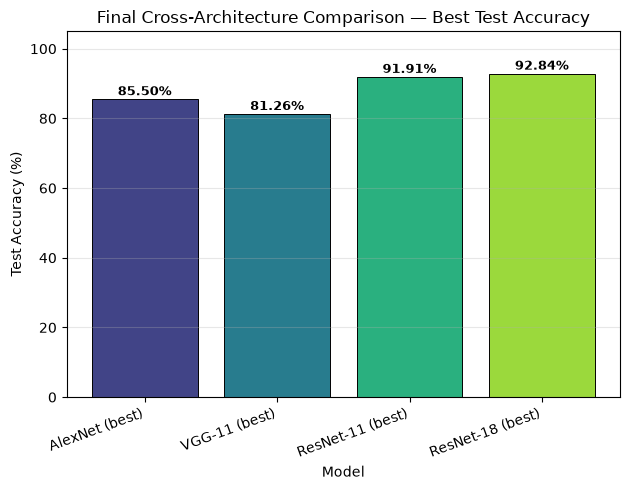

  Saved → output/q3/3b_final_comparison.png

  Architecture            Best Acc (%)
  ─────────────────────────────────────
  AlexNet (best)                 85.50
  VGG-11 (best)                  81.26
  ResNet-11 (best)               91.91
  ResNet-18 (best)               92.84

PROBLEM 3  Summary
  ResNet-11 p=0.0         : 91.82%
  ResNet-11 p=0.3         : 91.91% ◄ best
  ResNet-11 p=0.5         : 91.81%
  ResNet-18 p=0.0         : 92.76%
  ResNet-18 p=0.3         : 92.68%
  ResNet-18 p=0.5         : 92.84% ◄ best
  Saved → output/q3/results.json


In [ ]:
def main():
    print("=" * 60)
    print("Question 3: ResNet-11 vs ResNet-18 on CIFAR-10")
    print(f"Random seed : {SEED}")
    print("=" * 60)

    # ── Load earlier results (for final cross-architecture comparison) ─────────
    p1_results = load_results("output/q1")
    p2_results = load_results("output/q2")

    def _best_str(d, *keys):
        return f"{max(d.get(k, 0.0) for k in keys):.2f}%" if d else "N/A"

    if p1_results:
        print(f"\nLoaded P1 results\n AlexNet best acc: {_best_str(p1_results, 'baseline_acc', 'dropout_03_acc', 'dropout_05_acc')}")
    else:
        print("\nNo Problem 1 results found! Run problem1_alexnet.py first for the full cross-architecture comparison.")

    if p2_results:
        print(f"Loaded P2 results\n VGG-11 best acc: {_best_str(p2_results, 'baseline_acc', 'dropout_03_acc', 'dropout_05_acc')}")
    else:
        print("No Problem 2 results found — run problem2_vggnet.py first for the full cross-architecture comparison.")

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    set_seed(SEED)
    train_split, val_split, test_split = get_split(BATCH_SIZE)

    baseline_results = part_a(
        train_split, val_split, test_split, device
    )

    dropout_accs = part_b(
        baseline_results,
        train_split, val_split, test_split, device,
        p1_results, p2_results,
    )

    print("\n" + "=" * 60)
    print("PROBLEM 3  Summary")
    print("=" * 60)
    for mname, d in dropout_accs.items():
        best_acc = max(d.values())
        for variant, acc in d.items():
            marker = " ◄ best" if acc == best_acc else ""
            print(f"  {mname} {variant:<14}: {acc:.2f}%{marker}")

    save_results(out_path, {
        "seed"              : SEED,
        "epochs"            : NUM_EPOCHS,
        "batch_size"        : BATCH_SIZE,
        "lr"                : learning_rate,
        "weight_decay"      : weight_decay,
        "optimizer"         : "Adam",
        "scheduler"         : "CosineAnnealingLR",
        # ResNet-11
        "r11_params"        : baseline_results["ResNet-11"]["params"],
        "r11_baseline_acc"  : baseline_results["ResNet-11"]["test_acc"],
        "r11_dropout_03_acc": dropout_accs["ResNet-11"].get("p=0.3", 0.0),
        "r11_dropout_05_acc": dropout_accs["ResNet-11"].get("p=0.5", 0.0),
        "r11_best_acc"      : max(dropout_accs["ResNet-11"].values()),
        "r11_avg_epoch_time": baseline_results["ResNet-11"]["avg_time"],
        "r11_convergence_ep": baseline_results["ResNet-11"]["conv_ep"],
        # ResNet-18
        "r18_params"        : baseline_results["ResNet-18"]["params"],
        "r18_baseline_acc"  : baseline_results["ResNet-18"]["test_acc"],
        "r18_dropout_03_acc": dropout_accs["ResNet-18"].get("p=0.3", 0.0),
        "r18_dropout_05_acc": dropout_accs["ResNet-18"].get("p=0.5", 0.0),
        "r18_best_acc"      : max(dropout_accs["ResNet-18"].values()),
        "r18_avg_epoch_time": baseline_results["ResNet-18"]["avg_time"],
        "r18_convergence_ep": baseline_results["ResNet-18"]["conv_ep"],
    })

    return {
        "baseline_results": baseline_results,
        "dropout_accs"    : dropout_accs,
    }


if __name__ == "__main__":
    main()